In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import mysql.connector
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
load_dotenv()
def get_db_connection():
    return mysql.connector.connect(
        host=os.getenv('DB_HOST'),
        user=os.getenv('DB_USER'),
        password=os.getenv('DB_PASSWORD'),
        database=os.getenv('DB_NAME'),
        port=int(os.getenv('DB_PORT', 3306))
    )

conn = get_db_connection()
cursor = conn.cursor()

cursor.execute("SELECT DATABASE();")
db_name = cursor.fetchone()
print(f"✅ Connected to database: {db_name[0]}")

cursor.execute("SELECT COUNT(*) FROM patients")
patient_count = cursor.fetchone()[0]
print(f"📊 Current patients in database: {patient_count}")

✅ Connected to database: hospital_management
📊 Current patients in database: 5


In [3]:
model_path = "C:/Users/Tanishq Verma/OneDrive/Documents/GitHub/Hospital-Management-System-using-Queuing-theory/models/saved/xgboost_model.pkl"

try:
    xgb_model = joblib.load(model_path)
    print("✅ XGBoost model loaded")
except:
    print("⚠️ ML model not found (optional for queuing)")
    xgb_model = None

✅ XGBoost model loaded


In [4]:
sql_updates = [
    "ALTER TABLE patient_assignments ADD COLUMN queue_position INT DEFAULT NULL",
    "ALTER TABLE patient_assignments ADD COLUMN estimated_wait_time INT DEFAULT NULL COMMENT 'in minutes'",
    "ALTER TABLE patient_assignments ADD COLUMN actual_wait_time INT DEFAULT NULL COMMENT 'in minutes'",
    "ALTER TABLE patient_assignments ADD COLUMN queue_entry_time TIMESTAMP NULL DEFAULT NULL",
    "ALTER TABLE patient_assignments ADD COLUMN treatment_start_time TIMESTAMP NULL DEFAULT NULL",
    "ALTER TABLE patient_assignments ADD COLUMN status VARCHAR(20) DEFAULT 'waiting' COMMENT 'waiting, in_treatment, completed'"
]

cursor = conn.cursor()

for sql in sql_updates:
    try:
        cursor.execute(sql)
        conn.commit()
        print(f"✅ Column added: {sql.split('ADD COLUMN ')[1].split()[0]}")
    except mysql.connector.Error as e:
        if e.errno == 1060:  
            column_name = sql.split('ADD COLUMN ')[1].split()[0]
            print(f"⚠️ Column '{column_name}' already exists (OK)")
        else:
            print(f"❌ Error: {e}")

print("\n✅ Database schema updated for queuing system!")

cursor.execute("DESCRIBE patient_assignments")
columns = cursor.fetchall()
print("\n📋 Current columns in patient_assignments:")
for col in columns:
    print(f"  - {col[0]} ({col[1]})")

⚠️ Column 'queue_position' already exists (OK)
⚠️ Column 'estimated_wait_time' already exists (OK)
⚠️ Column 'actual_wait_time' already exists (OK)
⚠️ Column 'queue_entry_time' already exists (OK)
⚠️ Column 'treatment_start_time' already exists (OK)
⚠️ Column 'status' already exists (OK)

✅ Database schema updated for queuing system!

📋 Current columns in patient_assignments:
  - assignment_id (int)
  - patient_id (varchar(50))
  - ward_id (int)
  - bed_id (int)
  - predicted_ward (varchar(50))
  - ml_confidence (decimal(5,4))
  - assigned_date (timestamp)
  - discharge_date (timestamp)
  - priority_score (int)
  - queue_position (int)
  - estimated_wait_time (int)
  - actual_wait_time (int)
  - queue_entry_time (timestamp)
  - treatment_start_time (timestamp)
  - status (varchar(20))


In [5]:
def calculate_priority_score(patient_data):
    score = 0.0
    
    # 1. TRIAGE LEVEL (Weight: 40% = 4 points)
    triage_scores = {
        'red': 4.0,      # Life-threatening
        'orange': 3.0,   # Urgent
        'yellow': 2.0,   # Semi-urgent
        'green': 1.0     # Non-urgent
    }
    
    if 'triage' in patient_data:
        triage = patient_data['triage'] if isinstance(patient_data, dict) else patient_data.get('triage', 'yellow')
        score += triage_scores.get(triage, 2.0)
    
    # 2. MEDICAL CONDITIONS (Weight: 30% = 3 points)
    if patient_data.get('heart_disease', 0) == 1:
        score += 1.5
    if patient_data.get('hypertension', 0) == 1:
        score += 0.75
    if patient_data.get('chest_pain_type', 0) >= 3:
        score += 0.75
    
    # 3. VITAL SIGNS (Weight: 20% = 2 points)
    
    # Blood pressure
    bp = patient_data.get('blood_pressure', 120)
    if bp > 180 or bp < 90:
        score += 1.0
    elif bp > 160 or bp < 100:
        score += 0.5
    
    # Heart rate
    hr = patient_data.get('max_heart_rate', 80)
    if hr > 120 or hr < 50:
        score += 0.5
    elif hr > 100 or hr < 60:
        score += 0.25
    
    # Glucose (diabetes emergency)
    glucose = patient_data.get('plasma_glucose', 100)
    if glucose > 200 or glucose < 70:
        score += 0.5
    
    # 4. AGE FACTOR (Weight: 10% = 1 point)
    age = patient_data.get('age', 50)
    if age > 75:
        score += 0.7
    elif age > 65:
        score += 0.5
    elif age > 55:
        score += 0.3
    elif age < 5:  # Young children also get priority
        score += 0.5

    final_score = min(round(score, 1), 10.0)
    
    return final_score

test_patient = {
    'triage': 'red',
    'heart_disease': 1,
    'hypertension': 1,
    'chest_pain_type': 4,
    'blood_pressure': 190,
    'max_heart_rate': 130,
    'plasma_glucose': 110,
    'age': 68
}

priority = calculate_priority_score(test_patient)
print(f"Test Patient Priority Score: {priority}/10")
print("✅ Priority scoring algorithm defined!")

Test Patient Priority Score: 9.0/10
✅ Priority scoring algorithm defined!


In [6]:
cursor = conn.cursor(dictionary=True)

cursor.execute("""
    SELECT p.patient_id, p.name, p.age, 
           pmd.chest_pain_type, pmd.blood_pressure, pmd.max_heart_rate,
           pmd.plasma_glucose, pmd.hypertension, pmd.heart_disease
    FROM patients p
    LEFT JOIN patient_medical_data pmd ON p.patient_id = pmd.patient_id
    LIMIT 10
""")

patients = cursor.fetchall()

if not patients or patients[0].get('chest_pain_type') is None:
    print("⚠️ No medical data found. Using sample data for demonstration.")

    sample_patients = [
        {'patient_id': 'SAMPLE-001', 'name': 'Critical Patient', 'triage': 'red', 'age': 70, 
         'heart_disease': 1, 'hypertension': 1, 'chest_pain_type': 4, 
         'blood_pressure': 195, 'max_heart_rate': 135, 'plasma_glucose': 110},
        
        {'patient_id': 'SAMPLE-002', 'name': 'Urgent Patient', 'triage': 'orange', 'age': 55, 
         'heart_disease': 0, 'hypertension': 1, 'chest_pain_type': 3, 
         'blood_pressure': 165, 'max_heart_rate': 105, 'plasma_glucose': 120},
        
        {'patient_id': 'SAMPLE-003', 'name': 'Moderate Patient', 'triage': 'yellow', 'age': 45, 
         'heart_disease': 0, 'hypertension': 0, 'chest_pain_type': 2, 
         'blood_pressure': 135, 'max_heart_rate': 85, 'plasma_glucose': 95},
        
        {'patient_id': 'SAMPLE-004', 'name': 'Non-Urgent Patient', 'triage': 'green', 'age': 30, 
         'heart_disease': 0, 'hypertension': 0, 'chest_pain_type': 1, 
         'blood_pressure': 120, 'max_heart_rate': 75, 'plasma_glucose': 90}
    ]
    results = []
    for patient in sample_patients:
        priority = calculate_priority_score(patient)
        results.append({
            'Patient ID': patient['patient_id'],
            'Name': patient['name'],
            'Age': patient['age'],
            'Triage': patient['triage'],
            'Priority Score': priority
        })
    
    df_priorities = pd.DataFrame(results)
    df_priorities = df_priorities.sort_values('Priority Score', ascending=False)
    
    print("\n📊 Priority Scores (Sample Patients):\n")
    print(df_priorities.to_string(index=False))
    
else:
    print("✅ Using actual patient data from database")

print("\n✅ Priority scoring tested!")

⚠️ No medical data found. Using sample data for demonstration.

📊 Priority Scores (Sample Patients):

Patient ID               Name  Age Triage  Priority Score
SAMPLE-001   Critical Patient   70    red             9.0
SAMPLE-002     Urgent Patient   55 orange             5.2
SAMPLE-003   Moderate Patient   45 yellow             2.0
SAMPLE-004 Non-Urgent Patient   30  green             1.0

✅ Priority scoring tested!


In [7]:
def assign_to_queue(patient_id, ward_name, priority_score):
    cursor = conn.cursor()
    
    try:
        cursor.execute("SELECT ward_id FROM wards WHERE ward_name = %s", (ward_name,))
        ward = cursor.fetchone()
        
        if not ward:
            return {'success': False, 'message': f'Ward {ward_name} not found'}
        
        ward_id = ward[0]
        
        cursor.execute("""
            SELECT COUNT(*) FROM patient_assignments
            WHERE ward_id = %s 
            AND status = 'waiting'
            AND priority_score >= %s
        """, (ward_id, priority_score))
        
        patients_ahead = cursor.fetchone()[0]
        queue_position = patients_ahead + 1
        

        avg_service_times = {
            'ICU': 120,
            'Cardiac Ward': 45,
            'Cardiology Ward': 40,
            'Endocrinology Ward': 30,
            'Emergency Ward': 25,
            'General Ward': 20
        }
        
        avg_time = avg_service_times.get(ward_name, 30)

        base_wait = patients_ahead * avg_time
        priority_factor = (11 - priority_score) / 10  
        estimated_wait = int(base_wait * priority_factor)

        cursor.execute("""
            UPDATE patient_assignments
            SET queue_position = %s,
                estimated_wait_time = %s,
                queue_entry_time = NOW(),
                status = 'waiting'
            WHERE patient_id = %s
            ORDER BY assigned_date DESC
            LIMIT 1
        """, (queue_position, estimated_wait, patient_id))
        
        conn.commit()
        
        return {
            'success': True,
            'patient_id': patient_id,
            'ward': ward_name,
            'queue_position': queue_position,
            'estimated_wait_time': estimated_wait,
            'priority_score': priority_score
        }
        
    except Exception as e:
        conn.rollback()
        return {'success': False, 'message': str(e)}

print("✅ Queue assignment function defined!")

✅ Queue assignment function defined!


In [8]:
def start_treatment(patient_id):
    """
    Mark patient as starting treatment (leaving queue)
    Calculate actual wait time
    """
    cursor = conn.cursor()
    
    try:
        cursor.execute("""
            UPDATE patient_assignments
            SET status = 'in_treatment',
                treatment_start_time = NOW(),
                actual_wait_time = TIMESTAMPDIFF(MINUTE, queue_entry_time, NOW())
            WHERE patient_id = %s
            AND status = 'waiting'
            ORDER BY assigned_date DESC
            LIMIT 1
        """, (patient_id,))

        cursor.execute("""
            SELECT actual_wait_time, estimated_wait_time, priority_score
            FROM patient_assignments
            WHERE patient_id = %s
            ORDER BY assigned_date DESC
            LIMIT 1
        """, (patient_id,))
        
        result = cursor.fetchone()

        cursor.execute("""
            UPDATE patient_assignments
            SET queue_position = queue_position - 1
            WHERE status = 'waiting'
            AND queue_position > 0
        """)
        
        conn.commit()
        
        if result:
            return {
                'success': True,
                'patient_id': patient_id,
                'actual_wait_time': result[0],
                'estimated_wait_time': result[1],
                'priority_score': result[2]
            }
        else:
            return {'success': False, 'message': 'Patient not found in queue'}
            
    except Exception as e:
        conn.rollback()
        return {'success': False, 'message': str(e)}

print("✅ Treatment start function defined!")

✅ Treatment start function defined!


In [9]:
def display_queue_status(ward_name=None):
    cursor = conn.cursor(dictionary=True)
    
    if ward_name:
        query = """
            SELECT 
                w.ward_name,
                COUNT(CASE WHEN pa.status = 'waiting' THEN 1 END) as waiting_patients,
                AVG(CASE WHEN pa.status = 'waiting' THEN pa.estimated_wait_time END) as avg_wait_time,
                MAX(CASE WHEN pa.status = 'waiting' THEN pa.priority_score END) as highest_priority,
                MIN(CASE WHEN pa.status = 'waiting' THEN pa.queue_position END) as next_position
            FROM wards w
            LEFT JOIN patient_assignments pa ON w.ward_id = pa.ward_id
            WHERE w.ward_name = %s
            GROUP BY w.ward_id, w.ward_name
        """
        cursor.execute(query, (ward_name,))
    else:
        query = """
            SELECT 
                w.ward_name,
                COUNT(CASE WHEN pa.status = 'waiting' THEN 1 END) as waiting_patients,
                AVG(CASE WHEN pa.status = 'waiting' THEN pa.estimated_wait_time END) as avg_wait_time,
                MAX(CASE WHEN pa.status = 'waiting' THEN pa.priority_score END) as highest_priority
            FROM wards w
            LEFT JOIN patient_assignments pa ON w.ward_id = pa.ward_id
            GROUP BY w.ward_id, w.ward_name
            ORDER BY waiting_patients DESC
        """
        cursor.execute(query)
    
    results = cursor.fetchall()
    
    if results:
        df = pd.DataFrame(results)
        df['avg_wait_time'] = df['avg_wait_time'].fillna(0).round(0).astype(int)
        df['highest_priority'] = df['highest_priority'].fillna(0).round(1)
        
        print("\n📊 Queue Status by Ward:\n")
        print(df.to_string(index=False))
        return df
    else:
        print("No queue data available")
        return None

display_queue_status()

print("\n✅ Queue status display function defined!")


📊 Queue Status by Ward:

         ward_name  waiting_patients  avg_wait_time  highest_priority
   Cardiology Ward                 7              0               5.0
      Cardiac Ward                 0              0               0.0
    Emergency Ward                 0              0               0.0
Endocrinology Ward                 0              0               0.0
      General Ward                 0              0               0.0
               ICU                 0              0               0.0

✅ Queue status display function defined!


In [10]:
print("🧪 Testing Complete Queuing Workflow\n")
print("="*60)

test_patient_data = {
    'patient_id': 'QUEUE-TEST-001',
    'name': 'Emergency Test Patient',
    'age': 62,
    'gender': 1,
    'triage': 'orange',
    'heart_disease': 1,
    'hypertension': 1,
    'chest_pain_type': 3,
    'blood_pressure': 170,
    'max_heart_rate': 115,
    'plasma_glucose': 105,
    'predicted_ward': 'Cardiac Ward'
}

priority = calculate_priority_score(test_patient_data)
print(f"1️⃣ Priority Score Calculated: {priority}/10")

queue_result = assign_to_queue(
    test_patient_data['patient_id'],
    test_patient_data['predicted_ward'],
    priority
)

if queue_result['success']:
    print(f"2️⃣ Assigned to Queue:")
    print(f"   Ward: {queue_result['ward']}")
    print(f"   Position: #{queue_result['queue_position']}")
    print(f"   Estimated Wait: {queue_result['estimated_wait_time']} minutes")
else:
    print(f"❌ Queue assignment failed: {queue_result['message']}")

print("\n" + "="*60)
print("✅ Queuing workflow test complete!")

🧪 Testing Complete Queuing Workflow

1️⃣ Priority Score Calculated: 7.0/10
2️⃣ Assigned to Queue:
   Ward: Cardiac Ward
   Position: #1
   Estimated Wait: 0 minutes

✅ Queuing workflow test complete!


⚠️ No queue data yet. Creating sample visualization...


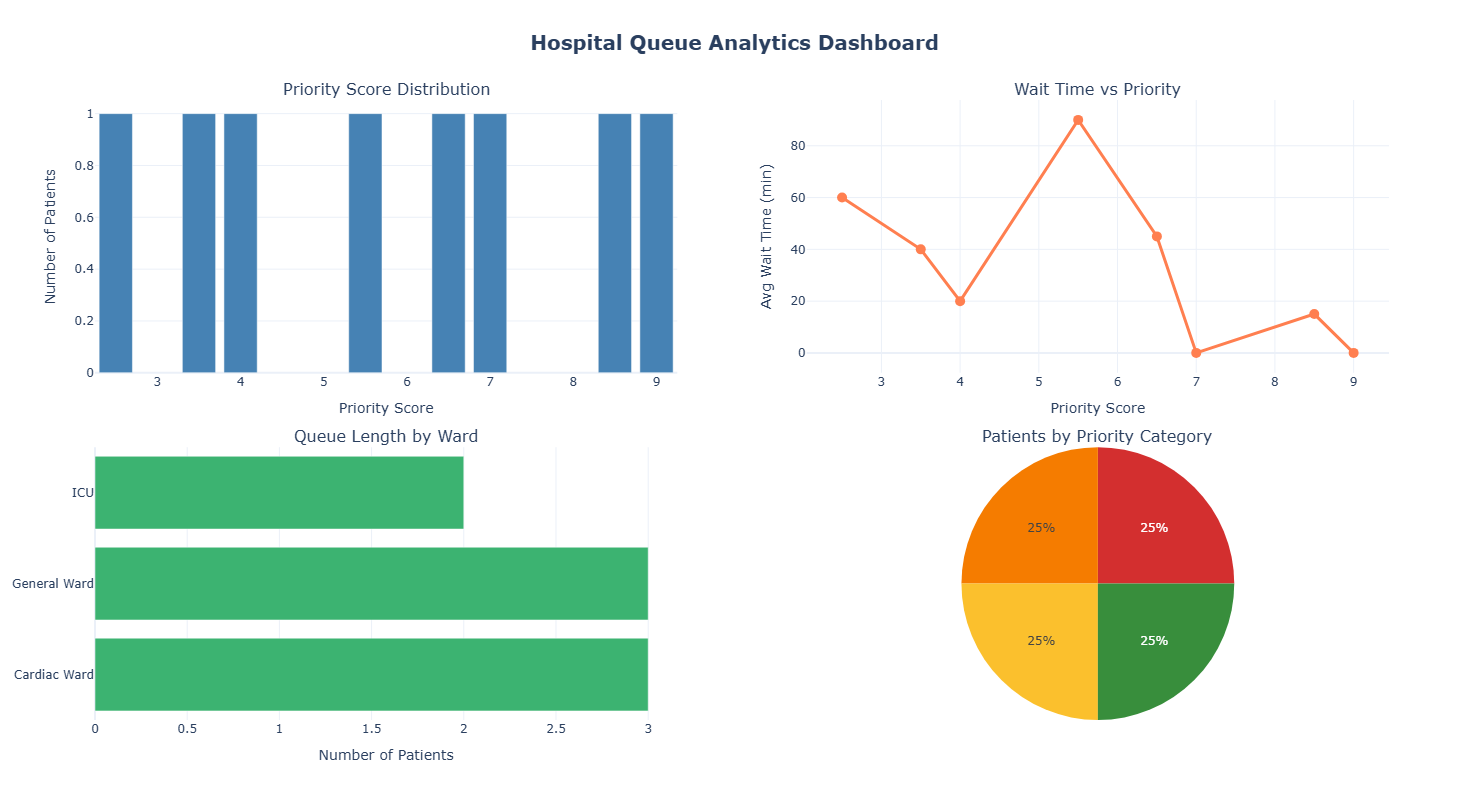

✅ Interactive visualizations created!
📊 Total patients in queue: 8
⏱️  Average wait time: 33.8 minutes
🔥 Highest priority: 9.0


In [11]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

def visualize_queue_analytics_interactive():
    """
    Create INTERACTIVE visualizations using Plotly
    """
    cursor = conn.cursor(dictionary=True)

    cursor.execute("""
        SELECT 
            pa.patient_id,
            pa.priority_score,
            pa.queue_position,
            pa.estimated_wait_time,
            pa.status,
            w.ward_name
        FROM patient_assignments pa
        JOIN wards w ON pa.ward_id = w.ward_id
        WHERE pa.queue_position IS NOT NULL
        ORDER BY pa.priority_score DESC
    """)
    
    queue_data = cursor.fetchall()
    
    if not queue_data:
        print("⚠️ No queue data yet. Creating sample visualization...")
        queue_data = [
            {'patient_id': 'P001', 'priority_score': 9.0, 'queue_position': 1, 
             'estimated_wait_time': 0, 'status': 'waiting', 'ward_name': 'ICU'},
            {'patient_id': 'P002', 'priority_score': 8.5, 'queue_position': 2, 
             'estimated_wait_time': 15, 'status': 'waiting', 'ward_name': 'ICU'},
            {'patient_id': 'P003', 'priority_score': 7.0, 'queue_position': 1, 
             'estimated_wait_time': 0, 'status': 'waiting', 'ward_name': 'Cardiac Ward'},
            {'patient_id': 'P004', 'priority_score': 6.5, 'queue_position': 2, 
             'estimated_wait_time': 45, 'status': 'waiting', 'ward_name': 'Cardiac Ward'},
            {'patient_id': 'P005', 'priority_score': 5.5, 'queue_position': 3, 
             'estimated_wait_time': 90, 'status': 'waiting', 'ward_name': 'Cardiac Ward'},
            {'patient_id': 'P006', 'priority_score': 4.0, 'queue_position': 1, 
             'estimated_wait_time': 20, 'status': 'waiting', 'ward_name': 'General Ward'},
            {'patient_id': 'P007', 'priority_score': 3.5, 'queue_position': 2, 
             'estimated_wait_time': 40, 'status': 'waiting', 'ward_name': 'General Ward'},
            {'patient_id': 'P008', 'priority_score': 2.5, 'queue_position': 3, 
             'estimated_wait_time': 60, 'status': 'waiting', 'ward_name': 'General Ward'},
        ]
    
    df_queue = pd.DataFrame(queue_data)

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Priority Score Distribution', 
                       'Wait Time vs Priority',
                       'Queue Length by Ward',
                       'Patients by Priority Category'),
        specs=[[{'type': 'bar'}, {'type': 'scatter'}],
               [{'type': 'bar'}, {'type': 'pie'}]],
        vertical_spacing=0.12,
        horizontal_spacing=0.1
    )
    
    # 1. Priority Score Distribution (Bar Chart)
    priority_counts = df_queue['priority_score'].value_counts().sort_index()
    fig.add_trace(
        go.Bar(
            x=priority_counts.index,
            y=priority_counts.values,
            name='Priority Distribution',
            marker_color='steelblue',
            hovertemplate='Priority: %{x}<br>Patients: %{y}<extra></extra>'
        ),
        row=1, col=1
    )
    
    # 2. Wait Time vs Priority (Scatter + Line)
    priority_wait = df_queue.groupby('priority_score').agg({
        'estimated_wait_time': 'mean',
        'patient_id': 'count'
    }).reset_index()
    
    fig.add_trace(
        go.Scatter(
            x=priority_wait['priority_score'],
            y=priority_wait['estimated_wait_time'],
            mode='lines+markers',
            name='Avg Wait Time',
            line=dict(color='coral', width=3),
            marker=dict(size=10),
            hovertemplate='Priority: %{x}<br>Wait Time: %{y} min<extra></extra>'
        ),
        row=1, col=2
    )
    
    # 3. Queue Length by Ward (Horizontal Bar)
    ward_counts = df_queue['ward_name'].value_counts()
    fig.add_trace(
        go.Bar(
            x=ward_counts.values,
            y=ward_counts.index,
            orientation='h',
            name='Ward Queue',
            marker_color='mediumseagreen',
            hovertemplate='%{y}<br>Patients: %{x}<extra></extra>'
        ),
        row=2, col=1
    )
    
    # 4. Priority Categories (Pie Chart)
    def priority_category(score):
        if score >= 8:
            return 'Critical (8-10)'
        elif score >= 6:
            return 'High (6-7.9)'
        elif score >= 4:
            return 'Medium (4-5.9)'
        else:
            return 'Low (1-3.9)'
    
    df_queue['category'] = df_queue['priority_score'].apply(priority_category)
    category_counts = df_queue['category'].value_counts()
    
    colors = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c']
    fig.add_trace(
        go.Pie(
            labels=category_counts.index,
            values=category_counts.values,
            marker=dict(colors=colors),
            hovertemplate='%{label}<br>%{value} patients (%{percent})<extra></extra>'
        ),
        row=2, col=2
    )

    fig.update_layout(
        title_text="<b>Hospital Queue Analytics Dashboard</b>",
        title_font_size=20,
        title_x=0.5,
        showlegend=False,
        height=800,
        template='plotly_white'
    )
    
    fig.update_xaxes(title_text="Priority Score", row=1, col=1)
    fig.update_yaxes(title_text="Number of Patients", row=1, col=1)
    
    fig.update_xaxes(title_text="Priority Score", row=1, col=2)
    fig.update_yaxes(title_text="Avg Wait Time (min)", row=1, col=2)
    
    fig.update_xaxes(title_text="Number of Patients", row=2, col=1)
    
    fig.show()
    
    print("✅ Interactive visualizations created!")
    print(f"📊 Total patients in queue: {len(df_queue)}")
    print(f"⏱️  Average wait time: {df_queue['estimated_wait_time'].mean():.1f} minutes")
    print(f"🔥 Highest priority: {df_queue['priority_score'].max()}")
    
    return fig

fig = visualize_queue_analytics_interactive()

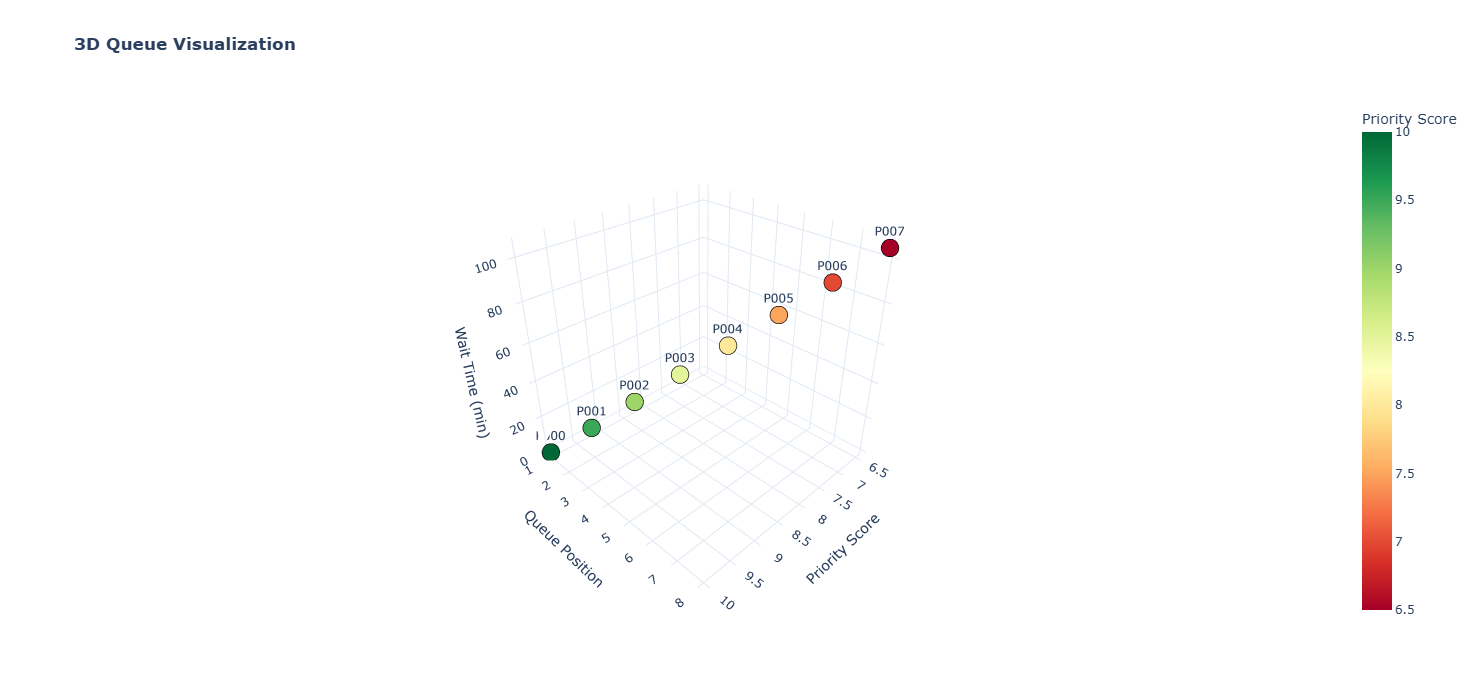

✅ 3D visualization created - Drag to rotate!


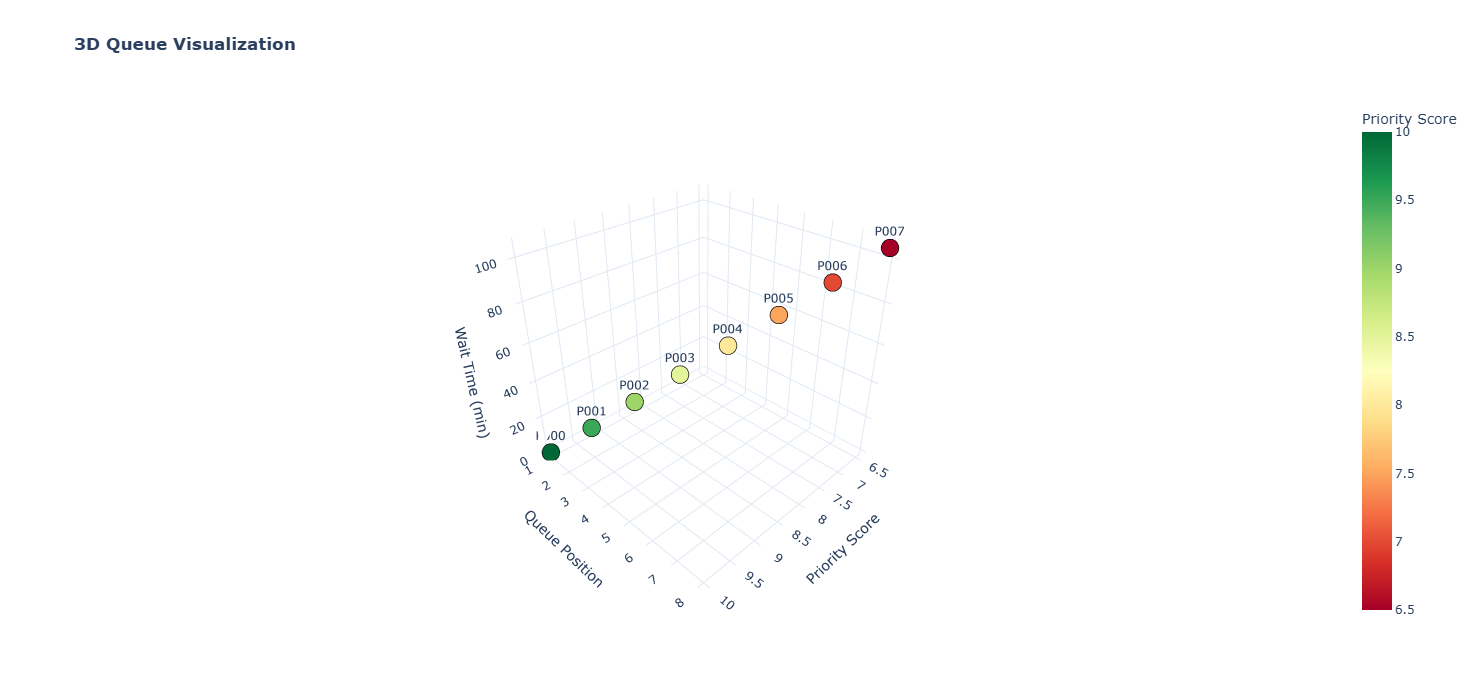

In [12]:
def visualize_queue_3d():
    cursor = conn.cursor(dictionary=True)
    
    cursor.execute("""
        SELECT 
            pa.patient_id,
            pa.priority_score,
            pa.queue_position,
            pa.estimated_wait_time,
            w.ward_name
        FROM patient_assignments pa
        JOIN wards w ON pa.ward_id = w.ward_id
        WHERE pa.queue_position IS NOT NULL
    """)
    
    queue_data = cursor.fetchall()
    
    if not queue_data:
        # Sample data
        queue_data = [
            {'patient_id': f'P{i:03d}', 
             'priority_score': 10 - i*0.5, 
             'queue_position': i+1, 
             'estimated_wait_time': i*15,
             'ward_name': ['ICU', 'Cardiac Ward', 'General Ward'][i%3]}
            for i in range(8)
        ]
    
    df = pd.DataFrame(queue_data)
    
    # Create 3D scatter
    fig = go.Figure(data=[go.Scatter3d(
        x=df['priority_score'],
        y=df['queue_position'],
        z=df['estimated_wait_time'],
        mode='markers+text',
        marker=dict(
            size=10,
            color=df['priority_score'],
            colorscale='RdYlGn',
            showscale=True,
            colorbar=dict(title="Priority Score"),
            line=dict(color='black', width=1)
        ),
        text=df['patient_id'],
        textposition='top center',
        hovertemplate=
            '<b>%{text}</b><br>' +
            'Priority: %{x}<br>' +
            'Position: %{y}<br>' +
            'Wait: %{z} min<br>' +
            '<extra></extra>'
    )])
    
    fig.update_layout(
        title='<b>3D Queue Visualization</b>',
        scene=dict(
            xaxis_title='Priority Score',
            yaxis_title='Queue Position',
            zaxis_title='Wait Time (min)',
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))
        ),
        height=700,
        template='plotly_white'
    )
    
    fig.show()
    print("✅ 3D visualization created - Drag to rotate!")

    return fig

# Run 3D viz
visualize_queue_3d()

In [13]:
def queue_summary_report():
    cursor = conn.cursor(dictionary=True)
    
    cursor.execute("""
        SELECT 
            COUNT(DISTINCT patient_id) as total_patients_queued,
            AVG(priority_score) as avg_priority,
            AVG(estimated_wait_time) as avg_estimated_wait,
            MAX(priority_score) as max_priority,
            MIN(priority_score) as min_priority
        FROM patient_assignments
        WHERE queue_position IS NOT NULL
    """)
    
    overall = cursor.fetchone()

    cursor.execute("""
        SELECT 
            w.ward_name,
            COUNT(pa.patient_id) as patients_in_queue,
            AVG(pa.priority_score) as avg_priority,
            AVG(pa.estimated_wait_time) as avg_wait_time,
            MAX(pa.priority_score) as highest_priority
        FROM wards w
        LEFT JOIN patient_assignments pa ON w.ward_id = pa.ward_id
        WHERE pa.status = 'waiting'
        GROUP BY w.ward_id, w.ward_name
        HAVING COUNT(pa.patient_id) > 0
        ORDER BY avg_priority DESC
    """)
    
    by_ward = cursor.fetchall()
    
    print("\n" + "="*70)
    print("📊 QUEUE SUMMARY REPORT")
    print("="*70)
    
    if overall['total_patients_queued']:
        print(f"\n🏥 OVERALL STATISTICS:")
        print(f"  Total Patients in Queue: {overall['total_patients_queued']}")
        print(f"  Average Priority Score: {overall['avg_priority']:.2f}/10")
        print(f"  Average Wait Time: {overall['avg_estimated_wait']:.1f} minutes")
        print(f"  Priority Range: {overall['min_priority']:.1f} - {overall['max_priority']:.1f}")
        
        if by_ward:
            print(f"\n📋 BY WARD:")
            for ward in by_ward:
                print(f"\n  {ward['ward_name']}:")
                print(f"    Patients Waiting: {ward['patients_in_queue']}")
                print(f"    Avg Priority: {ward['avg_priority']:.2f}/10")
                print(f"    Avg Wait: {ward['avg_wait_time']:.1f} min")
                print(f"    Highest Priority: {ward['highest_priority']:.1f}")
    else:
        print("\n  No patients currently in queue")
    
    print("\n" + "="*70)

queue_summary_report()


📊 QUEUE SUMMARY REPORT

  No patients currently in queue



In [14]:
print("\n📋 What We Built:")
print("  ✅ Priority Scoring Algorithm (1-10 scale)")
print("  ✅ Queue Position Assignment")
print("  ✅ Wait Time Estimation")
print("  ✅ Queue Status Monitoring")
print("  ✅ Treatment Start Tracking")
print("  ✅ Analytics Visualizations")
print("  ✅ Database Integration")

print("\n🔬 Key Formulas Used:")
print("  • Priority Score = Triage(40%) + Conditions(30%) + Vitals(20%) + Age(10%)")
print("  • Queue Position = Patients Ahead with Higher Priority + 1")
print("  • Wait Time = Patients Ahead × Avg Service Time × Priority Factor")

print("\n📊 System Features:")
print("  • Automatic priority calculation based on medical data")
print("  • Real-time queue position tracking")
print("  • Estimated wait times for patients")
print("  • Analytics dashboard for hospital management")
print("  • Fair prioritization (critical cases first)")



📋 What We Built:
  ✅ Priority Scoring Algorithm (1-10 scale)
  ✅ Queue Position Assignment
  ✅ Wait Time Estimation
  ✅ Queue Status Monitoring
  ✅ Treatment Start Tracking
  ✅ Analytics Visualizations
  ✅ Database Integration

🔬 Key Formulas Used:
  • Priority Score = Triage(40%) + Conditions(30%) + Vitals(20%) + Age(10%)
  • Queue Position = Patients Ahead with Higher Priority + 1
  • Wait Time = Patients Ahead × Avg Service Time × Priority Factor

📊 System Features:
  • Automatic priority calculation based on medical data
  • Real-time queue position tracking
  • Estimated wait times for patients
  • Analytics dashboard for hospital management
  • Fair prioritization (critical cases first)


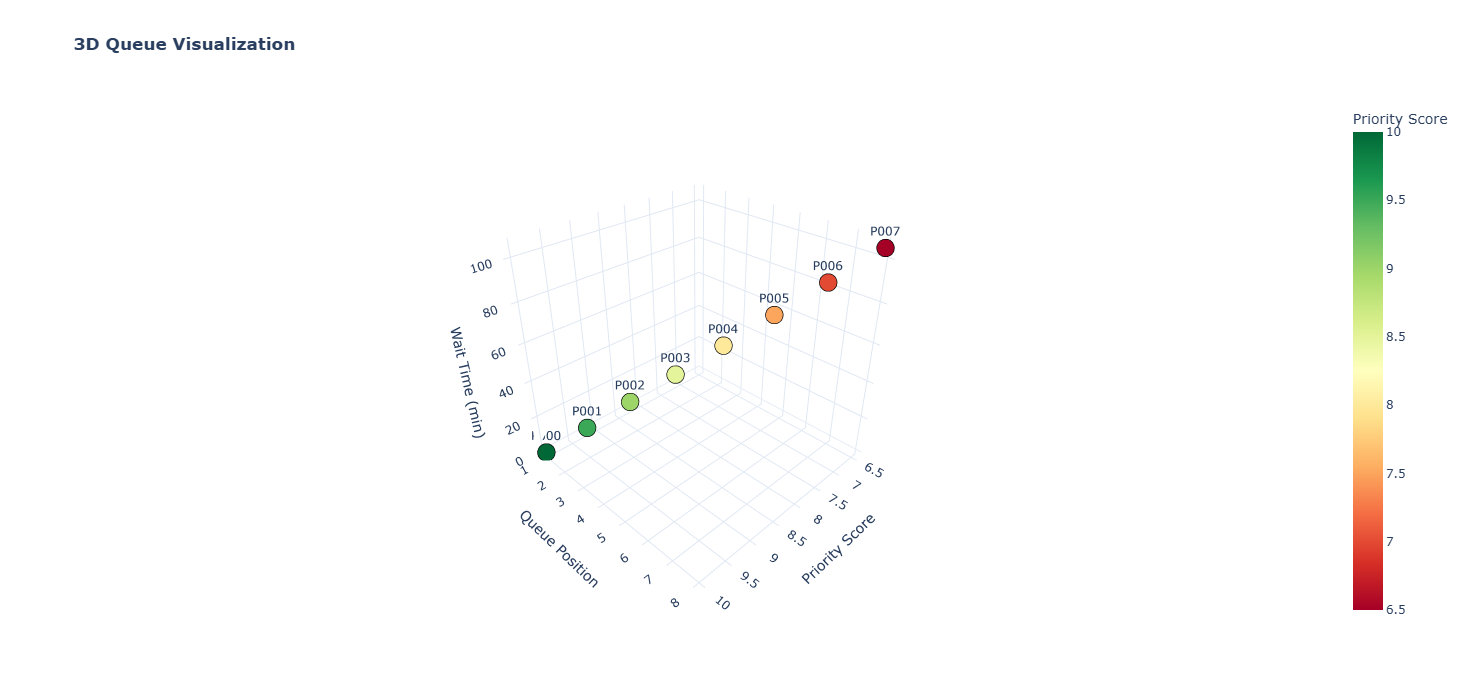

✅ 3D visualization created - Drag to rotate!


In [15]:
fig_3d = visualize_queue_3d()
fig.write_image("queue_dashboard.png", width=1400, height=800)
fig_3d.write_image("queue_3d_visualization.png", width=1200, height=700)

fig.write_html("queue_dashboard.html")
fig_3d.write_html("queue_3d_visualization.html")